### plan

#### TODO milestone 1 : working neurons and network with synthetic inputs
- simple neuron implementation
- simple network implementation
- output graphs implementation

#### TODO milestone 2 : MNIST simple example
- STDP, learning
- feedforward, fully connected networks
- ...

#### TODO milestone 3 : small integration and comparision with SNNtorch
- surrogate gradients 
- recurring networks
- other types of networks
- other types of neurons
- ...
- fast sigmoid

#### TODO milestone 4: visualization experiments, with and without mini implementation
- layer, neuron, output, input visualizer (seperate module, and can work with both this and snntorch)

#### TODO milestone 5 : comparision with different SNNN-RL methods
- R-STDP
- eligibility traces
- ... 

#### TODO milestone 6 : optimized runs, insights
- GPU integration
- ...

In [29]:
import numpy as np

In [30]:
num_steps = 32

input = np.random.randint(low=0, high=2, size=num_steps)

print(input)

[1 0 1 0 1 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0]


In [31]:
class LIF_neuron:
    threshold = 5

    def __init__(self, threshold, id):
        self.threshold = threshold
        self.temp_threshold = 0
        self.id = id

    def update(self):
        if self.temp_threshold >= self.threshold:
            self.fire()

    def fire(self):
        print(f"neuron {self.id} fired")


In [32]:
neuron = LIF_neuron(10, 0)

neuron.update()

#### neurons

total current in the circuit is conserved:
$$ I_{in}(t) = I_R + I_C$$

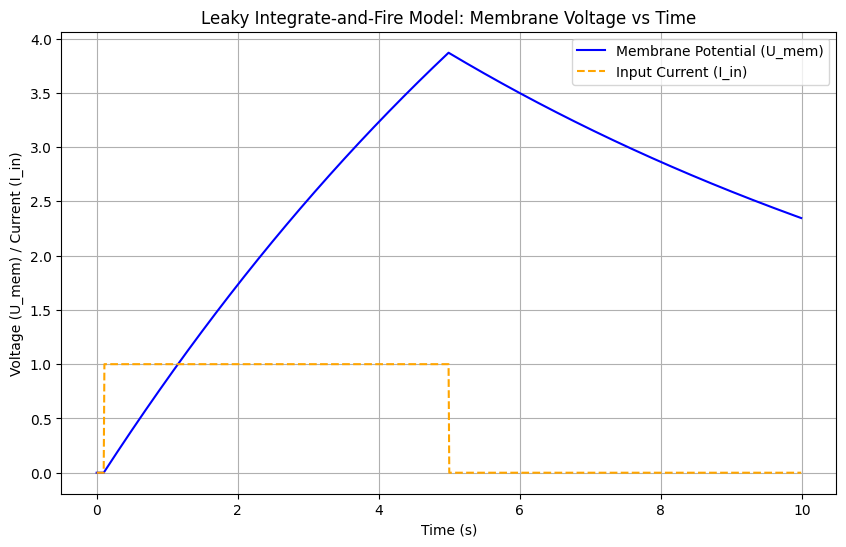

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
R = 10.0  # Resistance (Ohms)
C = 1.0   # Capacitance (Farads)
tau = R * C  # Time constant
dt = 0.01    # Time step (seconds)
time_steps = 1000  # Total number of steps

# Input current function (pulse input)
def I_in(t):
    return 1.0 if 0.1 < t < 5 else 0.0  # Pulse between t=0.1 and t=0.5
    

# Initialize variables
U_mem = 0.0  # Initial membrane potential
time = np.arange(0, time_steps * dt, dt)  # Time array
voltage = []  # Voltage over time array

# Simulation loop
for t in time:
    dU_mem = (-U_mem + R * I_in(t)) / tau  # Compute the derivative
    U_mem += dU_mem * dt  # Update the membrane voltage
    voltage.append(U_mem)

# Visualization
plt.figure(figsize=(10, 6))

# Plot membrane voltage
plt.plot(time, voltage, label='Membrane Potential (U_mem)', color='blue')

# Plot input current for reference
input_current = [I_in(t) for t in time]
plt.plot(time, input_current, label='Input Current (I_in)', linestyle='--', color='orange')

# Labels and legend
plt.title("Leaky Integrate-and-Fire Model: Membrane Voltage vs Time")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (U_mem) / Current (I_in)")
plt.legend()
plt.grid()
plt.show()
